In [1]:
# Euskera v1.0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd ..

/Users/armandoroqueestrada/Euskera_data/Euskera_github


Euskera v1.

In this notebook, we show an illustrative examples of how to determine the oscillating frequency of the soliton simulation from the simulation data. For more details, see the documentation.

In [ ]:
import euskera as eu

import numpy as np
import matplotlib.pyplot as plt

from scipy import interpolate

In order to identify the frequency, we need to used the background profile. In this case, we use the results corresponding to solitons without self-interaction in the $n = 0$ and $n = 1$ states.

In [8]:
# loading the profiles
dataEx = np.load("profiles/profiles_const_lam_0_n_0_1.npz", allow_pickle=True)['arr_0']

In [10]:
### Generating the profiles data with an iteration dx
dx = 0.00001

parameters = ['profiles', 'potential_profiles', 'E_data', 'M_data', 'lambda']
data_Proca = {key: [] for key in parameters} # to save the mass for each profile
##################################################################
for s0 in dataEx:
    Ei, Mass, rDnew, sDnew, dsDnew, uDnew, duDnew, LamV = s0
    
    ### scaling to Euskera variables
    rE = rDnew/np.sqrt(2)
    sd = sDnew/np.sqrt(2*np.pi)
    LambdaV = 4 * np.pi * LamV
        
    rad2 = np.arange(rE[0], rE[-1], dx)
    ftemp = interpolate.interp1d(rE, sd)  # interpolating
    sdE2x = ftemp(rad2)

    ftemp = interpolate.interp1d(rE, Ei - uDnew)
    uDnewE2x = ftemp(rad2)

    # computing the mass
    Mas = eu.massVal(rE, sd, gamma=0, fac=4*np.pi, kind='quadratic', fill_value="extrapolate")    
    
    data_Proca['profiles'].append(sdE2x)
    data_Proca['potential_profiles'].append(uDnewE2x)
    data_Proca['E_data'].append(Ei)
    data_Proca['M_data'].append(Mas)
    data_Proca['lambda'].append(LambdaV)

    print("Energy -> ", Ei)    
    print("Mass using Euskera -> ", Mas, "Mass using convertion -> ", Mass/(np.sqrt(2*np.pi)**2*np.sqrt(2)**3)) # check

Energy ->  -0.9789591957601331
Mass using Euskera ->  2.4524274612065935 Mass using convertion ->  2.452427458457671
Energy ->  -0.9162746282239667
Mass using Euskera ->  5.454587177838958 Mass using convertion ->  5.454587152796816


## Simulation information

First we considert the $n=0$ case

In [12]:
# Simulation data
address = 'simulation_data/profile_soliton_n_0/'
name = "parameters.txt"
format =  eu.give_parameter(address + name, "format")
save_number =  eu.give_parameter(address + name, "save_number")
step_factor =  eu.give_parameter(address + name, "step_factor")
gridlength =  eu.give_parameter(address + name, "gridlength")
tmax =  eu.give_parameter(address + name, "tmax")
resol =  eu.give_parameter(address + name, "resol")
Plim = eu.give_parameter(address + name, "Plim")

print(address, '\n', format, '\n', save_number)

# Identifying the file names
filenames = eu.nameData(address, format, info=True)
print(filenames)

simulation_data/profile_soliton_n_0/ 
 npz 
 400
Found 6 files with the .npz extension.
['end_save_line_psi.npz', 'end_save_plane_rho.npz', 'end_save_line_rho.npz', 'end_grid.npz', 'end_save_energies.npz', 'end_save_line_phi.npz']


In [13]:
# extracting the grid coordinates
if 'end_grid.npz' in filenames:
    temp = np.load(address + f"/{'end_grid.npz'}")
    grid = [temp[cord] for cord in ['x', 'y', 'z']]
    print("save grid")

# extracting the conserv.
conserv = {"Numb_Part": None, "Energ": None, "Pi": None, "Ji": None, "Frequency": None}
if 'end_save_energies.npz' in filenames:
    temp = np.load(address + f"/{'end_save_energies.npz'}", allow_pickle=True)
    nump_energ = np.array([temp['save_energies%s'%num] for num in range(0, save_number+1)])

    ind = 0
    for cons_name in conserv:
        if eu.give_parameter(address + name, cons_name):
            conserv[cons_name] = nump_energ[:, ind]
            ind += 1
    print("save conserved quantities")

# extracting the x-proyections
names_lineal = {'end_save_line_psi.npz': None,
         'end_save_line_rho.npz': None,
         'end_save_line_phi.npz': None
}
for temp_name in names_lineal:
    if temp_name in filenames:
        temp = np.load(address + f"/{temp_name}")
        names_lineal[temp_name] = [temp['%s%s'%(temp_name[4:-4], num)] for num in range(0, save_number+1)]
        print("save x proyection ", temp_name)

save grid
save conserved quantities
save x proyection  end_save_line_psi.npz
save x proyection  end_save_line_rho.npz
save x proyection  end_save_line_phi.npz


In [14]:
# Time of simulation, intervalor's time, etc.

ht, its_per_save, num_steps = eu.dtime(tmax, gridlength, resol, step_factor, save_number)

dt = its_per_save * ht
print("Time between saved iteration (n -> %d) "%its_per_save, dt)
print("Total time -> ", dt * save_number, " (equivalent to tmax) ", tmax)

Time between saved iteration (n -> 7)  0.5
Total time ->  200.0  (equivalent to tmax)  200.0


#### Computing the Frequency

First, we use the saved “Frequency” data to identify the $\Psi$ frequency using both the shooting and FFT methods. Later, this will be scaled to identify the frequency with the boundary condition $U = 0$. For details see the documentation,

ω estimado: 0.8917466532076979
A estimado: 0.37656784618544104
Error:  [2.28760287e-05 4.33262886e-06]

Frequency ω ≈ 0.8774523122 rad/s
Fase estimada: 1.43 rad

Shooting frequency:              0.9789591957601331
Simulation frequency, method 1:  0.8917466532076979
Simulation frequency, method 2:  0.8774523122245805
##################################################


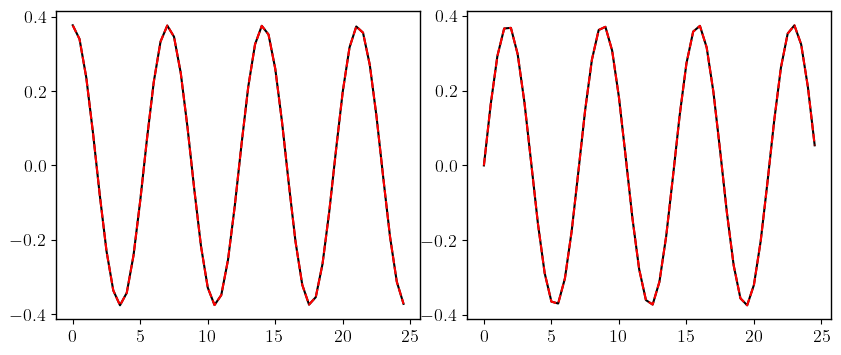

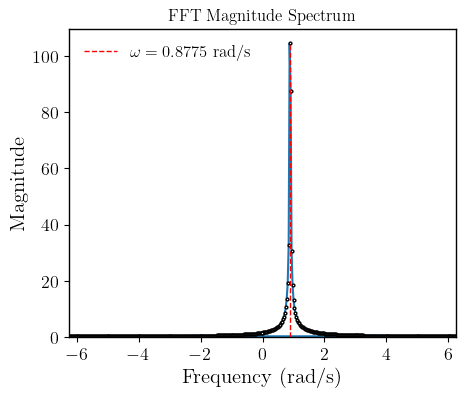

In [50]:
index = 0  # index 0 is n=0, index 1 is n=1

data_freq = conserv["Frequency"]
times_data = np.arange(len(data_freq)) * dt

guess = - data_Proca['E_data'][index]
rangIndex = 50
data, error = eu.main_frequency(data_freq[:rangIndex], times_data[:rangIndex], met=1, guess=guess, info=True)[0]
print()
metod2 = eu.main_frequency(data_freq, times_data, met=2, info=True)[0]

print()
print("Shooting frequency:             ", guess)
print("Simulation frequency, method 1: ", data[1])
print("Simulation frequency, method 2: ", metod2)
print('#'*50)

#### Illustrative plots

Next we shows the $x$-component of $|\Psi|$ and its potential $U$. In addition we present the shooting results (background profiles)

Text(-37, 0.038, 'Time $0$')

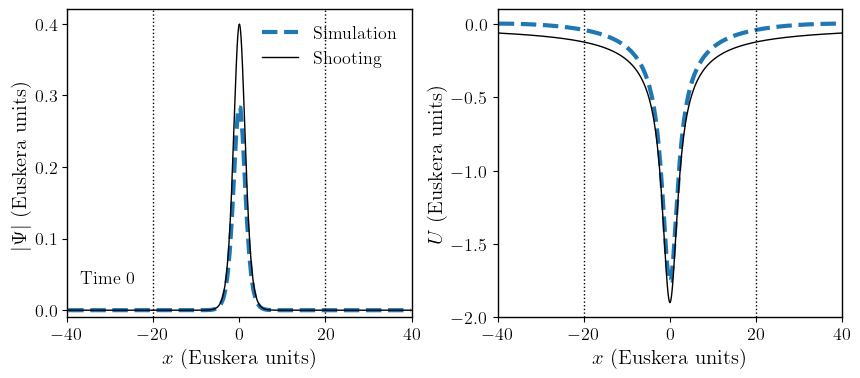

In [51]:
# Plot the initial profile previous to the scaling
time = 0
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.15, wspace=.25))

fProca = data_Proca['profiles'][index]
ax[0].plot(grid[0], np.abs(np.real(names_lineal['end_save_line_psi.npz'][frame][0])), ls='--', lw=3, label='Simulation')
ax[0].plot(np.arange(len(fProca))*dx, np.abs(np.real(fProca*np.exp(1j*guess*time))), ls='-', c='k', lw=1, label='Shooting')
ax[0].plot(-np.arange(len(fProca))*dx, np.abs(np.real(fProca*np.exp(1j*guess*time))), ls='-', c='k', lw=1)

ax[0].legend(frameon=False, loc='upper right', fontsize=13)
ax[0].set_ylabel(r'$|\Psi|$ (Euskera units)')
######
UProca = data_Proca['potential_profiles'][index]
ax[1].plot(grid[0], names_lineal['end_save_line_phi.npz'][frame], ls='--', lw=3)
ax[1].plot(np.arange(len(UProca))*dx, UProca, -np.arange(len(UProca))*dx, UProca, ls='-', c='k', lw=1)

ax[1].set_ylabel(r'$U$ (Euskera units)')


ax[0].set_ylim(-0.01, 0.42)
ax[1].set_ylim(-2, 0.1)
######
for axes in ax:
      axes.set_xlim(-gridlength/2, gridlength/2)
      axes.set_xlabel(r'$x$ (Euskera units)')
      axes.vlines(Plim, *axes.get_ylim(), ls=':', color='k', lw=1)
      axes.vlines(-Plim, *axes.get_ylim(), ls=':', color='k', lw=1)

ax[0].text(-37, 0.038, rf"Time ${time}$", fontsize=13)

#### Scaling

To determine the physical frequency, we first need to identify the scaling constant using the last frame

In [53]:
# constant
frame = save_number
c = min(names_lineal['end_save_line_phi.npz'][frame]) - min(UProca)
print("Scaling constant -> ", c)

Scaling constant ->  0.14758954809396885


In [55]:
w = data[1]  # frequency simulation by shooting
print('Scaled Frequency:','w_{sim} + c = w_{shot}')
print('Frequency shooting:', guess)
print('Simulation frequency: ', rf"%4.3f + %4.3f = %4.3f"%(w, c, w+c))

Scaled Frequency: w_{sim} + c = w_{shot}
Frequency shooting: 0.9789591957601331
Simulation frequency:  0.892 + 0.148 = 1.039


Text(-37, -1.8, '$0.892 + 0.148 \\to 1.039$')

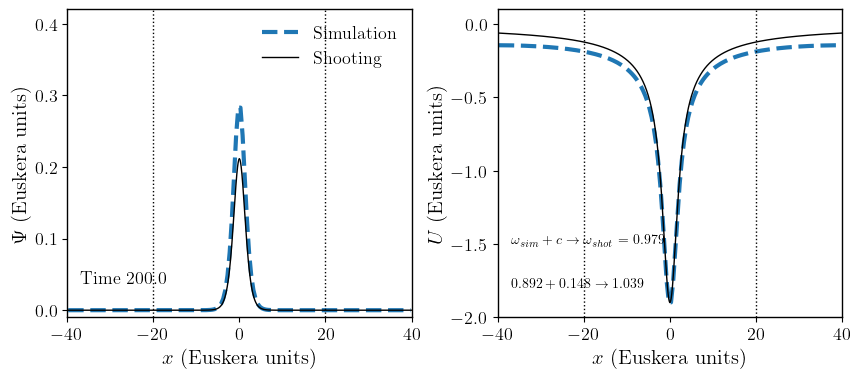

In [ ]:
time = frame*dt

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.15, wspace=.25))

fProca = data_Proca['profiles'][index]
ax[0].plot(grid[0], np.abs(np.real(names_lineal['end_save_line_psi.npz'][frame][0])), ls='--', lw=3, label='Simulation')
ax[0].plot(np.arange(len(fProca))*dx, np.abs(np.real(fProca*np.exp(1j*guess*time))), ls='-', c='k', lw=1, label='Shooting')
ax[0].plot(-np.arange(len(fProca))*dx, np.abs(np.real(fProca*np.exp(1j*guess*time))), ls='-', c='k', lw=1)

ax[0].legend(frameon=False, loc='upper right', fontsize=13)
ax[0].set_ylabel(r'$\Psi$ (Euskera units)')

######
UProca = data_Proca['potential_profiles'][index]
ax[1].plot(grid[0], names_lineal['end_save_line_phi.npz'][frame] - c, ls='--', lw=3)
ax[1].plot(np.arange(len(UProca))*dx, UProca, -np.arange(len(UProca))*dx, UProca, ls='-', c='k', lw=1)

ax[1].set_ylabel(r'$U$ (Euskera units)')


ax[0].set_ylim(-0.01, 0.42)
ax[1].set_ylim(-2, 0.1)
######
for axes in ax:
      axes.set_xlim(-gridlength/2, gridlength/2)
      axes.set_xlabel(r'$x$ (Euskera units)')
      axes.vlines(Plim, *axes.get_ylim(), ls=':', color='k', lw=1)
      axes.vlines(-Plim, *axes.get_ylim(), ls=':', color='k', lw=1)

ax[0].text(-37, 0.038, rf"Time ${time}$", fontsize=13)


ax[1].text(-37, -1.5, r"$\omega_{sim} + c \to \omega_{shot} = %4.3f $"%guess, fontsize=10)
ax[1].text(-37, -1.8, rf"$%4.3f + %4.3f \to %4.3f$"%(w, c, w+c), fontsize=10)